# **Profissional Reconhecimento de Padrões**

In [9]:
import pandas as pd

# Definindo os dados como um dicionário para criar o DataFrame
dados = {
    "Objeto": [
        "Objeto_1", "Objeto_2", "Objeto_3", "Objeto_4", "Objeto_5",
        "Objeto_6", "Objeto_7", "Objeto_8", "Objeto_9", "Objeto_10"
    ],
    "Cor": [
        "Vermelho", "Azul", "Amarelo", "Azul", "Vermelho",
        "Verde", "Amarelo", "Verde", "Vermelho", "Azul"
    ],
    "Forma": [
        "Círculo", "Quadrado", "Triângulo", "Círculo", "Quadrado",
        "Triângulo", "Círculo", "Quadrado", "Triângulo", "Círculo"
    ],
    "Tamanho": [
        "Pequeno", "Médio", "Grande", "Pequeno", "Médio",
        "Grande", "Médio", "Grande", "Pequeno", "Médio"
    ],
    "Textura": [
        "Liso", "Rugoso", "Liso", "Rugoso", "Liso",
        "Rugoso", "Liso", "Rugoso", "Liso", "Rugoso"
    ],
    "Classe": [
        "Classe_A", "Classe_B", "Classe_C", "Classe_B", "Classe_A",
        "Classe_C", "Classe_A", "Classe_B", "Classe_C", "Classe_B"
    ]
}

# Criando o DataFrame
df = pd.DataFrame(dados)

# Visualizando
display(df.head())


,Objeto,Cor,Forma,Tamanho,Textura,Classe
0,Objeto_1,Vermelho,Círculo,Pequeno,Liso,Classe_A
1,Objeto_2,Azul,Quadrado,Médio,Rugoso,Classe_B
2,Objeto_3,Amarelo,Triângulo,Grande,Liso,Classe_C
3,Objeto_4,Azul,Círculo,Pequeno,Rugoso,Classe_B
4,Objeto_5,Vermelho,Quadrado,Médio,Liso,Classe_A


/tmp/ipython-input-8-3296795777.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2')
/tmp/ipython-input-8-3296795777.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2')
/tmp/ipython-input-8-3296795777.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2')
/tmp/ipython-input-8-3296795777.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `lege

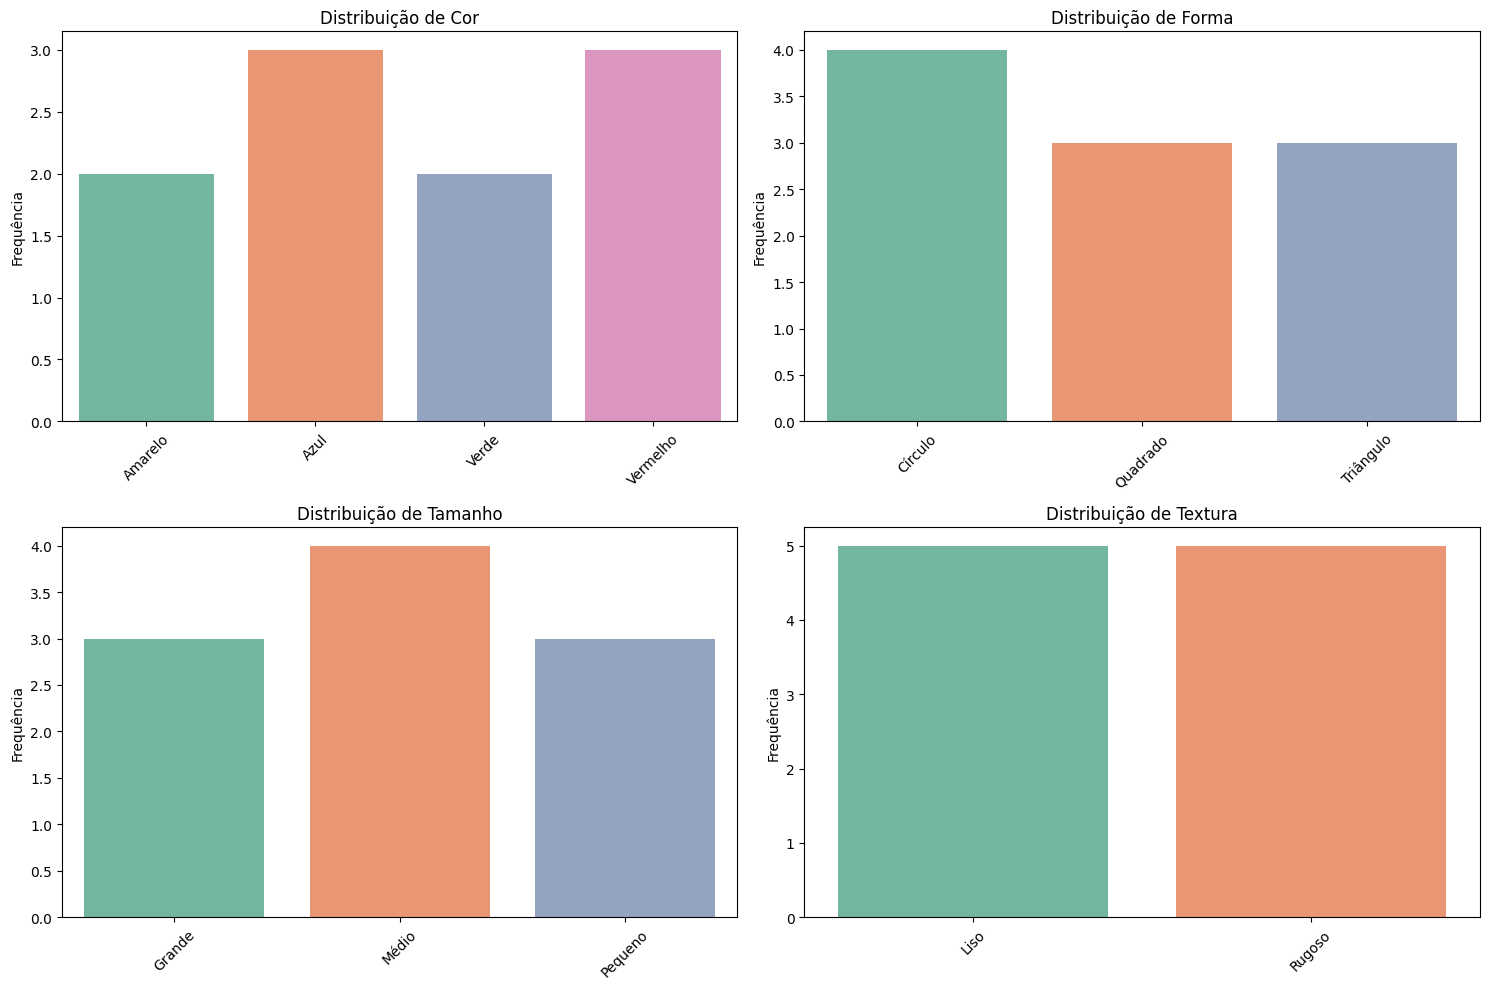

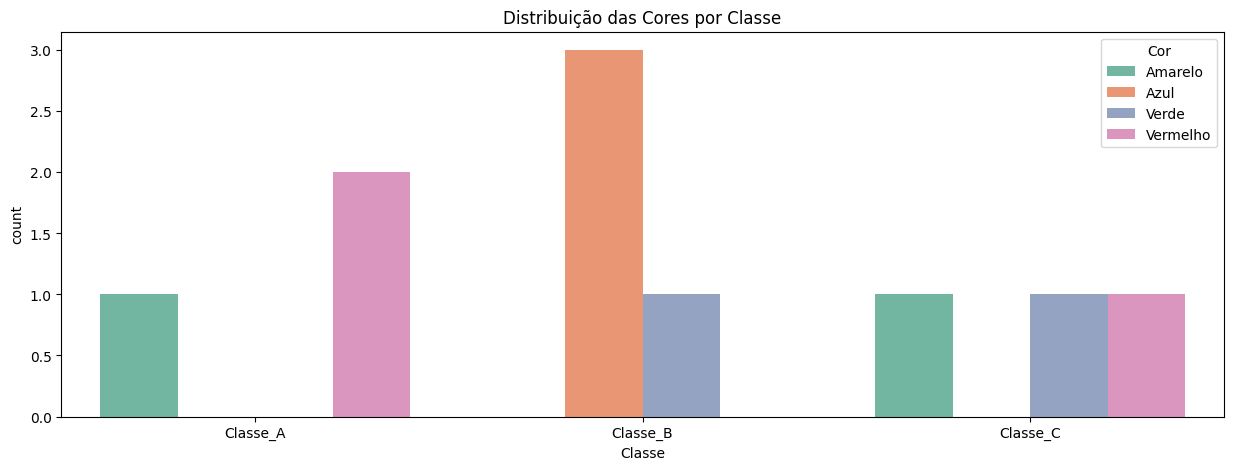

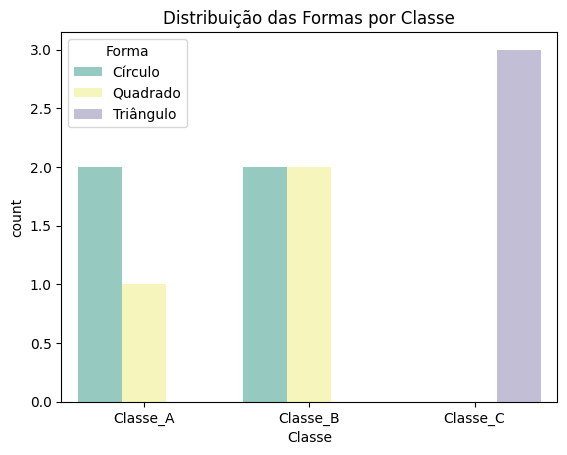

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convertendo colunas categóricas para categóricas do pandas
for col in ['Cor', 'Forma', 'Tamanho', 'Textura', 'Classe']:
    df[col] = df[col].astype('category')

# Tabela de frequência das variáveis
frequencias = {col: df[col].value_counts() for col in ['Cor', 'Forma', 'Tamanho', 'Textura', 'Classe']}

# Visualizações
plt.figure(figsize=(15, 10))
for i, col in enumerate(['Cor', 'Forma', 'Tamanho', 'Textura']):
    plt.subplot(2, 2, i+1)
    sns.countplot(x=col, data=df, palette='Set2')
    plt.title(f'Distribuição de {col}')
    plt.xticks(rotation=45)
    plt.xlabel('')
    plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

# Gráfico de barras agrupado por Classe
plt.figure(figsize=(15, 5))
sns.countplot(x="Classe", hue="Cor", data=df, palette="Set2")
plt.title("Distribuição das Cores por Classe")
plt.show()

sns.countplot(x="Classe", hue="Forma", data=df, palette="Set3")
plt.title("Distribuição das Formas por Classe")
plt.show()

## Visualização de Padrões com PCA
Nesta etapa, aplicamos a Análise de Componentes Principais (PCA) para transformar nosso conjunto de dados multivariado (com 4 atributos) em apenas duas dimensões (PC1 e PC2).

Isso permite visualizar graficamente os objetos e observar se existem agrupamentos ou padrões que se relacionam com as classes alvo.

#### 🧠 O que você está vendo neste gráfico:
Cada ponto representa um objeto do conjunto de dados.

A posição dos pontos é resultado de uma transformação matemática (PCA) que tenta manter a maior variabilidade possível dos dados originais.

As cores dos pontos representam a classe à qual cada objeto pertence (Classe_A, Classe_B, Classe_C).

Se os pontos da mesma cor estiverem próximos entre si, isso significa que os objetos daquela classe compartilham padrões semelhantes nos atributos (cor, forma, tamanho e textura).

#### 🧩 Por que isso é importante?
Essa visualização permite que:

Identifiquemos se há separabilidade entre as classes com base nos atributos atuais.

Avaliemos se os atributos são suficientes para treinar um modelo de classificação.

Iniciemos a discussão sobre aprendizado supervisionado, já que as classes são conhecidas e servem como referência.

#### 🤔 Perguntas para reflexão em sala:
* As classes estão bem separadas ou se sobrepõem?

* Quais atributos podem estar influenciando mais a separação?

* O que poderia tornar essa separação mais clara? (ex: adicionar mais atributos?)

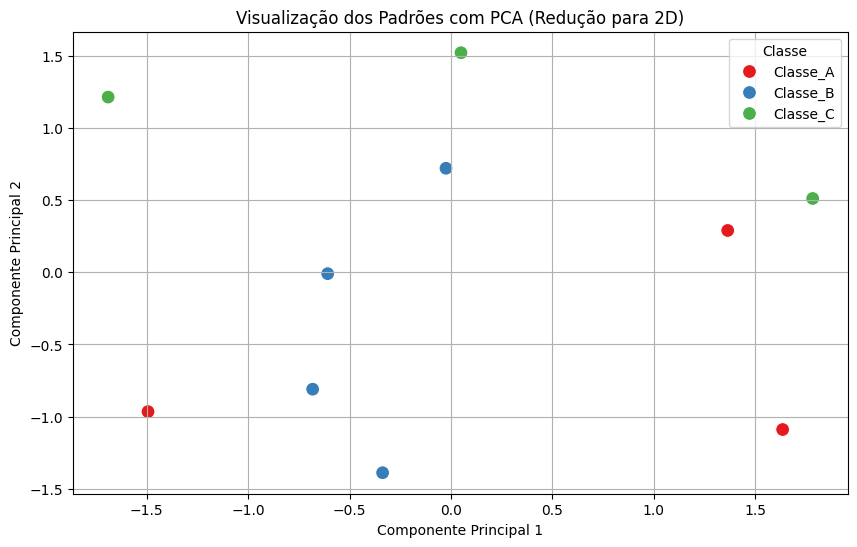

In [10]:
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

# Codificando as variáveis categóricas para análise com PCA
df_encoded = df.copy()
le_dict = {}

for col in ['Cor', 'Forma', 'Tamanho', 'Textura', 'Classe']:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    le_dict[col] = le  # Armazenar para decodificação futura se necessário

# Separando atributos e rótulos
X = df_encoded[['Cor', 'Forma', 'Tamanho', 'Textura']]
y = df_encoded['Classe']

# Aplicando PCA para reduzir a dimensionalidade para 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Criando um DataFrame para visualização
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Classe'] = df['Classe']

# Plotando os dados reduzidos
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Classe', palette='Set1', s=100)
plt.title('Visualização dos Padrões com PCA (Redução para 2D)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Classe')
plt.grid(True)
plt.show()


### 🔍 Correlação entre os Atributos

Antes de aplicar qualquer algoritmo, é essencial entender **como os atributos do nosso conjunto de dados se relacionam entre si**.

Usamos uma matriz de correlação para medir o **grau de relação entre variáveis numéricas codificadas**. O valor da correlação varia de -1 a 1:

- **1** = correlação positiva perfeita
- **-1** = correlação negativa perfeita
- **0** = nenhuma correlação

> Como nosso conjunto de dados tem variáveis originalmente categóricas, usamos a versão codificada numericamente para gerar o mapa de calor.

Isso nos ajuda a:
- Detectar **atributos redundantes**
- Identificar **padrões entre variáveis**
- Compreender quais atributos podem ter mais influência na classificação final


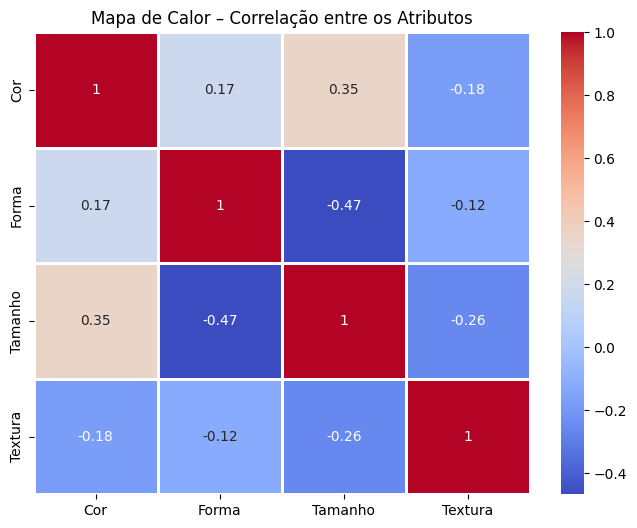

In [11]:
# Gerando a matriz de correlação dos atributos codificados
correlation_matrix = df_encoded[['Cor', 'Forma', 'Tamanho', 'Textura']].corr()

# Visualizando com um mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=1, linecolor='white')
plt.title('Mapa de Calor – Correlação entre os Atributos')
plt.show()


### 🧩 Agrupamento com K-Means

**K-Means** é uma técnica de **aprendizado não supervisionado** usada para **agrupar dados com base em similaridade**.

Diferente dos modelos supervisionados (que usam rótulos ou classes conhecidas), o K-Means tenta **descobrir padrões escondidos** nos dados e dividir os pontos em **k grupos (clusters)** com base na distância entre eles.

#### Como funciona:
1. Escolhemos o número de grupos **k** (neste exemplo, vamos usar 3).
2. O algoritmo posiciona **centros (centroides)** aleatórios.
3. Cada ponto é atribuído ao centro mais próximo.
4. O algoritmo ajusta os centros e repete até a convergência.

> Nosso objetivo aqui é verificar se os objetos se agrupam de forma similar às classes conhecidas (`Classe_A`, `Classe_B`, `Classe_C`) — mesmo sem usar os rótulos.

#### Por que isso é útil?
- Permite validar se há **estrutura natural nos dados**.
- É uma forma prática de mostrar **padrões emergentes**.
- Ótimo para ensinar como funciona o **reconhecimento de padrões não supervisionado**.


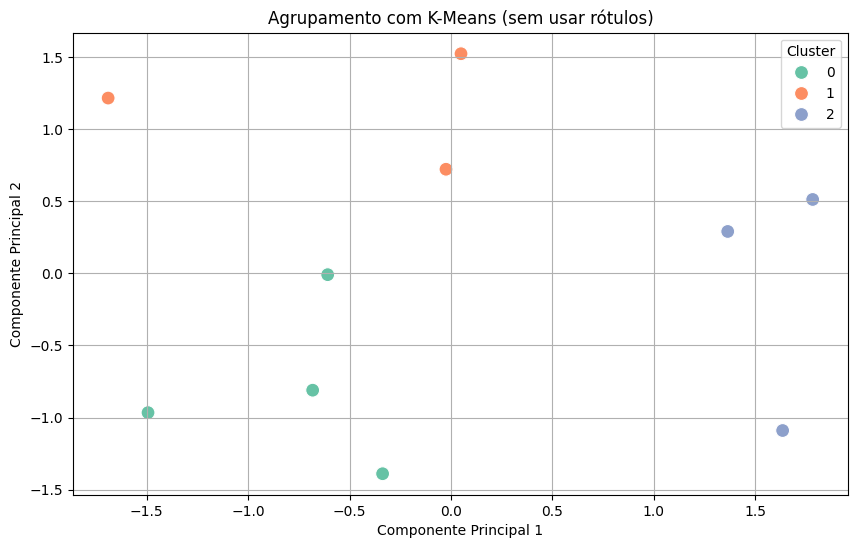

In [12]:
from sklearn.cluster import KMeans

# Aplicando KMeans para 3 clusters (hipótese: 3 classes)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)

# Criando um novo DataFrame com os clusters
df_pca['Cluster'] = clusters

# Visualizando os clusters com base nas componentes principais
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Cluster', palette='Set2', s=100)
plt.title('Agrupamento com K-Means (sem usar rótulos)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()


### 🌳 Construção de uma Árvore de Decisão

A **Árvore de Decisão** é um algoritmo de **aprendizado supervisionado** que funciona como um processo de perguntas "Sim ou Não" até chegar a uma **classificação final**.

Ela é fácil de interpretar e muito usada quando se deseja **explicar decisões** baseadas em atributos observáveis.

#### Como funciona:
- O algoritmo escolhe o **atributo mais informativo** para dividir os dados (ex: Cor, Tamanho, Forma...).
- Cria **ramificações** com base nas respostas.
- Continua dividindo até que cada grupo (folha) esteja **puro** (ou quase puro) para uma classe.

#### Por que usar?
- Permite ensinar **como o modelo “pensa”** para tomar decisões.
- Visualmente ajuda os alunos a enxergarem o **reconhecimento de padrões supervisionado**.
- Pode ser usado como **base para modelos mais complexos**, como Random Forest.



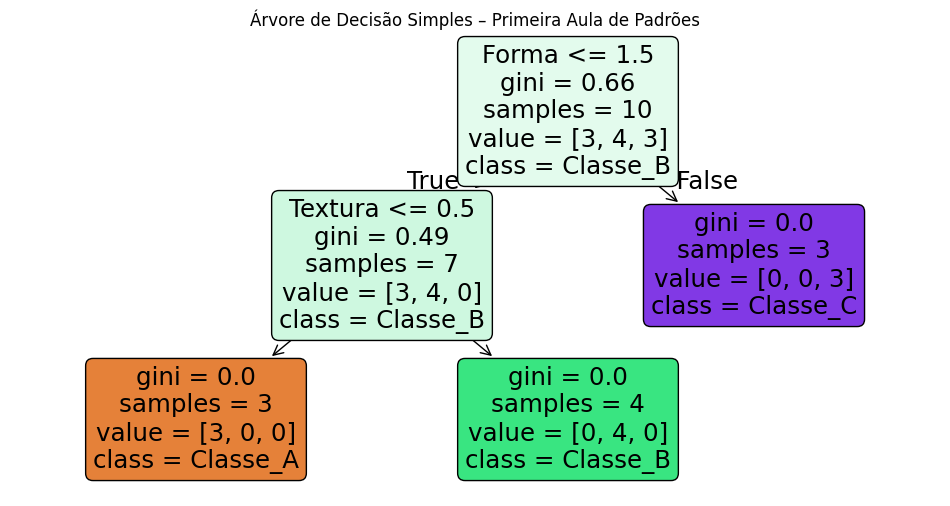

In [16]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Árvore com profundidade máxima de 2
clf_simplificada = DecisionTreeClassifier(max_depth=2, random_state=42)
clf_simplificada.fit(X, y)

# Visualização simplificada
plt.figure(figsize=(12, 6))
plot_tree(
    clf_simplificada,
    feature_names=X.columns,
    class_names=le_dict['Classe'].classes_,
    filled=True,
    rounded=True
)
plt.title('Árvore de Decisão Simples – Primeira Aula de Padrões')
plt.show()



## 🌳 Como interpretar a Árvore de Decisão?

A árvore de decisão mostra como o algoritmo faz escolhas com base nos dados. Cada bloco (nó) apresenta informações importantes. Vamos entender o que significa cada item:

---

### ✅ 1. **Condição** (ex: `Forma <= 1.5`)
É a regra usada para dividir os dados.

- Exemplo: `Forma <= 1.5` → separa os objetos com Forma codificada até 1.5 (à esquerda) dos outros (à direita).

---

### 🔁 2. **`gini`** – Impureza de Gini
Indica o **nível de mistura de classes** naquele nó.

- `gini = 0.0` → nó puro (uma única classe)
- `gini` próximo de `0.5 ou mais` → mistura de classes

💡 Quanto **menor o Gini**, **melhor a separação** das classes.

---

### 🔢 3. **`samples`**
Quantidade de exemplos (linhas) que chegaram a esse nó.

- Exemplo: `samples = 4` → há 4 objetos analisados neste ponto da árvore.

---

### 📊 4. **`value`**
Mostra a quantidade de exemplos de cada classe nesse nó.

- Exemplo: `value = [2, 1, 1]` significa:
  - 2 objetos da Classe_A
  - 1 objeto da Classe_B
  - 1 objeto da Classe_C

---

### 🏷️ 5. **`class = Classe_X`**
É a **classe majoritária** naquele nó. Se parássemos a análise ali, essa seria a **previsão final**.

---

### 👁️‍🗨️ Exemplo completo:

```plaintext
Forma <= 1.5
gini = 0.66
samples = 10
value = [3, 4, 3]
class = Classe_B
